In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta, date
from dateutil.relativedelta import relativedelta
from lifelines import KaplanMeierFitter, AalenJohansenFitter
from lifelines.utils import datetimes_to_durations
from matplotlib.ticker import MultipleLocator
ruta_archivo ="C:/Users/AnaMaríaRamírezLizár/PROYECTOS/data/Base de datos.xlsx"
ruta_cierres = "C:/Users/AnaMaríaRamírezLizár/SUPERIA CAPITAL\Operacion - Credito y Riesgo - Credito y Riesgo/ADMIN INTEGRAL DE RIESGO\PORTAFOLIO MANAGMENT/Analisis/Cierre LDC.xlsx"

<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332\3682370221.py:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  ruta_cierres = "C:/Users/AnaMaríaRamírezLizár/SUPERIA CAPITAL\Operacion - Credito y Riesgo - Credito y Riesgo/ADMIN INTEGRAL DE RIESGO\PORTAFOLIO MANAGMENT/Analisis/Cierre LDC.xlsx"


# Análisis de Cosechas PAY

Calcula el porcentaje de capital vencido por mes de originación y MOB (Months on Books) para el producto PAY, y lo visualiza como un heatmap.

In [19]:
data_credito = pd.read_excel(ruta_archivo, sheet_name='Creditos')
data_abonos = pd.read_excel(ruta_archivo, sheet_name='Abonos')
data_clientes = pd.read_excel(ruta_archivo, sheet_name='Clientes')
data_cierres = pd.read_excel(ruta_cierres, sheet_name='Cierres')
data_cierres = data_cierres.rename(columns={'Linea': 'Line'})

data_pm=data_clientes.loc[data_clientes['Person Type']=="MORAL",'Person Id']
dcred_pm= data_credito[data_credito['Person Id'].isin(data_pm)]
data_ldc=dcred_pm[(dcred_pm['Is line']=="SI")&(dcred_pm['Loan Status']=="AUTORIZADO")]
data_ldc=data_ldc.rename(columns={'Cosecha':'Originacion'})
data_ldc['RFC']=data_ldc['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
data_min=dcred_pm[dcred_pm['Loan Type']=="MINISTRACION"]
data_min['Originacion']=data_min['Line'].map(data_ldc.set_index('Line')['Originacion'])
data_min['RFC']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
data_min['Status']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Status'])
data_ldc['Status']=np.where(pd.to_datetime(data_ldc['Due Date'])<pd.to_datetime(date.today()),'INACTIVO','ACTIVO')

pay=data_min[data_min['Product'].str.contains('PAY')]

C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332\1364749629.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_min['Originacion']=data_min['Line'].map(data_ldc.set_index('Line')['Originacion'])
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332\1364749629.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_min['RFC']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332

In [20]:
payb=data_abonos[data_abonos['Product'].str.contains('PAY')]
pay=pay.rename(columns={'Period Number':'Cuotas'})
payb=payb.rename(columns={'Installment':'Cuota'})
payb['Originacion']=payb['Portfolio Id'].map(pay.set_index('Portfolio Id')['Originacion'])
#Unificar cuotas que se pagaron por partes
pagos_agrup= (
    payb.groupby(['Portfolio Id', 'Cuota']).agg({'Application Date': 'max','Capital':'sum','Penalty':'sum'}).reset_index()
)
#Insertar filas por ministraciones
pagos=pay.loc[pay.index.repeat(pay['Cuotas'])].assign(Cuota=lambda x: x.groupby('Portfolio Id').cumcount()+1)
payc=pagos.merge(pagos_agrup,on=['Portfolio Id','Cuota'],how='left')
payc['Application Date']=pd.to_datetime(payc['Application Date']).fillna(date.today())
def fcp(row):
  duedate=pd.to_datetime(row['Opening Date'])+relativedelta(months=row['Cuota'])
  return duedate

payc['Fecha vencimiento cuota']=payc.apply(fcp,axis=1)
payc=payc[pd.to_datetime(payc['Fecha vencimiento cuota'],errors='coerce')<=pd.to_datetime(date.today())]
payc['Moratorios']=payc['Penalty'].fillna(0)
def mobp1(row):
    dy=(pd.to_datetime(row['Opening Date']).year)-(pd.to_datetime(row['Originacion']).year)
    dm=(pd.to_datetime(row['Opening Date']).month)-(pd.to_datetime(row['Originacion']).month)
    MOBop=dy*12+dm+row['Cuota']
    return MOBop

payc['MOB']=payc.apply(mobp1,axis=1)#Meses en llibros

def dpdp(row):
  duedate=pd.to_datetime(row['Opening Date'])+relativedelta(months=row['Cuota'])
  DPDUP= pd.to_numeric((pd.to_datetime(row['Application Date'])-duedate).days,errors='coerce')
  if DPDUP<0:
    return 0
  else:
    if row['Loan Status']=="LIQUIDADO":
      if row['Moratorios']>0:
        return DPDUP
      else:
        return 0
    else:
      if pd.to_datetime(row['Application Date'])!=pd.to_datetime(date.today()):
        if row['Moratorios']>0:
          return DPDUP
        else:
          return 0
      else:
        return DPDUP

payc['DPD']=payc.apply(dpdp,axis=1) #Dias de atraso

def DPADP(fila):
    if fila['DPD']>0:
      return fila['Capital']
    else:
      return 0

payc['mvenc']=payc.apply(DPADP,axis=1)
def propmp(fil):
  if fil['Amount']==0:
    return 0
  else:
    return fil['mvenc']/fil['Amount']

fi=pd.to_datetime(input("Desde qué fecha deseas analizar: "))
ff=pd.to_datetime(input("Hasta qué fecha deseas analizar: "))
filtrop=payc[(payc['Originacion']>=fi) & (payc['Originacion']<=ff)]
sit_vencp=pd.pivot_table(
    filtrop,
    index=pd.Grouper(key='Originacion',freq='1M'),
    values=['mvenc'],
    aggfunc='sum'
)

filtro_monp=data_ldc[(data_ldc['Product'].str.contains('PAY')) & (data_ldc['Originacion']>=fi) & (data_ldc['Originacion']<=ff)]
sit_monp=pd.pivot_table(
    filtro_monp,
    index=pd.Grouper(key='Originacion',freq='1M'),
    values=['Amount'],
    aggfunc='sum'
)


sitp=pd.merge(sit_vencp,sit_monp,on='Originacion')

sit_vencp=sit_vencp.reset_index()
sit_monp=sit_monp.reset_index()

sitp['Indice']=sitp.apply(propmp,axis=1)


coh_datap=filtrop.groupby([pd.Grouper(key='Originacion',freq='1M'),'MOB'])['mvenc'].apply(np.sum)
coh_datap=coh_datap.reset_index()

coh_morap=coh_datap.pivot_table(
                              index='Originacion',
                              columns='MOB',
                              values='mvenc')


coh_desp=filtro_monp.groupby([pd.Grouper(key='Originacion',freq='1M')])['Amount'].apply(np.sum)
coh_desp=coh_desp.reset_index()

coh_count_desp =coh_desp.pivot_table(
                              index=pd.Grouper(key="Originacion",freq='1M'),
                              values='Amount')



#indicadores de columnas
indcp=coh_morap.divide(coh_count_desp.iloc[:,0],axis=0)
indcp=(indcp*100).round(4).dropna(how='all')
indcp.index=indcp.index.strftime('%Y-%m')

C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332\1812063113.py:68: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key='Originacion',freq='1M'),
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332\1812063113.py:76: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key='Originacion',freq='1M'),
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332\1812063113.py:90: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  coh_datap=filtrop.groupby([pd.Grouper(key='Originacion',freq='1M'),'MOB'])['mvenc'].apply(np.sum)
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_18332\1812063113.py:99: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  coh_desp=filtro_monp.groupby([pd.Grouper(key='Originacion',freq='1M')])[

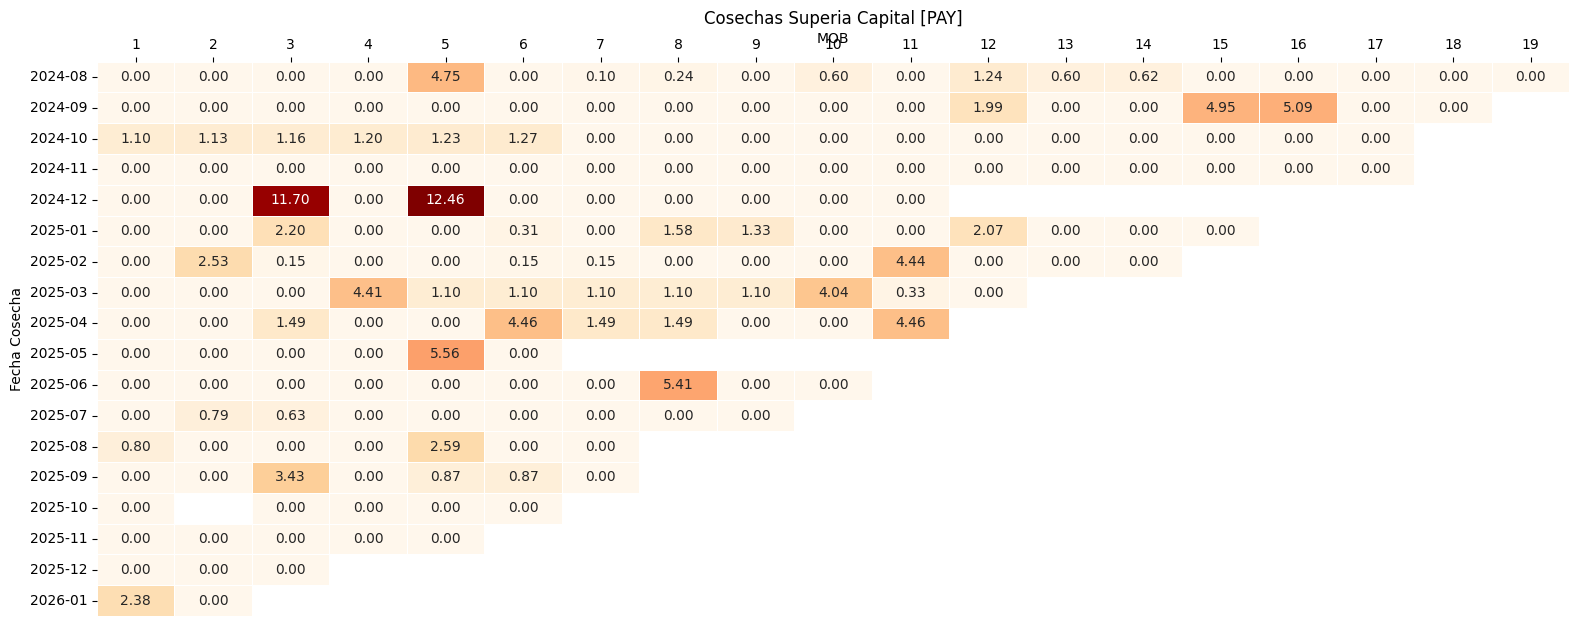

In [21]:
rows,cols=indcp.shape #Para ajuste de tamaño
plt.figure(figsize=(cols*1,rows*0.4))
ax=sns.heatmap(indcp,annot= True,cmap="OrRd",fmt='.2f',linewidths=.5,cbar=False)
ax.xaxis.tick_top()
ax.xaxis.label_position='top'
ax.set(title='Cosechas Superia Capital [PAY]',ylabel='Fecha Cosecha')
plt.show()

# Fase 1 — Exploración de Datos (EDA)

El objetivo de esta sección es conocer la estructura y calidad de todas las fuentes de datos que se usarán en el modelo predictivo de riesgo PAY.

## 1. Carga de tablas adicionales

In [22]:
# Tablas financieras y de comportamiento crediticio
data_balance      = pd.read_excel(ruta_archivo, sheet_name='balance_sheet')
data_income       = pd.read_excel(ruta_archivo, sheet_name='income_statement')
data_cashflow     = pd.read_excel(ruta_archivo, sheet_name='cash_flow')
data_invoices     = pd.read_excel(ruta_archivo, sheet_name='annual_invoices_comparisons')
data_employees    = pd.read_excel(ruta_archivo, sheet_name='employees')
data_entity       = pd.read_excel(ruta_archivo, sheet_name='superia_entity')

# Tablas de Buró de Crédito
data_score        = pd.read_excel(ruta_archivo, sheet_name='csv_score')
data_vc_pyme      = pd.read_excel(ruta_archivo, sheet_name='csv_vc_pyme')

# Tabla de registro de evaluación crediticia
data_registro     = pd.read_excel(ruta_archivo, sheet_name='xls_registro')

print("Tablas cargadas correctamente.")

Tablas cargadas correctamente.


## 2. Estructura de cada tabla

Dimensiones, tipos de datos y primeras filas de cada fuente.

In [23]:
tablas = {
    'pay (ministraciones PAY)' : pay,
    'data_balance'             : data_balance,
    'data_income'              : data_income,
    'data_cashflow'            : data_cashflow,
    'data_invoices'            : data_invoices,
    'data_employees'           : data_employees,
    'data_entity'              : data_entity,
    'data_score'               : data_score,
    'data_vc_pyme'             : data_vc_pyme,
    'data_registro'            : data_registro,
}

for nombre, df in tablas.items():
    print(f"{'='*55}")
    print(f"  {nombre}")
    print(f"  Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
    print(f"  Columnas: {list(df.columns)}")
    print()

  pay (ministraciones PAY)
  Filas: 275  |  Columnas: 35
  Columnas: ['Portfolio Id', 'External Code', 'Line', 'Person Id', 'Name', 'Product', 'Is line', 'Loan Type', 'Interest Rate', 'Penalty Interest Rate', 'Internal Return Rate', 'Annual Internal Return Rate', 'Total Annual Cost', 'Profitability', 'Signature Date', 'Opening Date', 'Due Date', 'Disbursement Date', 'Amount', 'Desk Exchange Rate', 'Agreed Exchange Rate', 'Daily Spread', 'Currency', 'Payment Currency', 'Disbursed Currency', 'Installment Period', 'Cuotas', 'Closing Day', 'Profit (USD)', 'Profit (MXN)', 'Loan Status', 'Cosecha', 'Originacion', 'RFC', 'Status']

  data_balance
  Filas: 2,445  |  Columnas: 21
  Columnas: ['id', 'profile_id', 'year', 'total_assets', 'current_assets', 'cash_equivalents', 'accounts_receivable', 'inventory', 'lt_asset', 'property_plant_equipment', 'intangible_assets', 'total_liabilities', 'common_stock', 'sh_equity', 'retained_earnings', 'current_liabilities', 'lt_liabilities', 'current_debt', 

## 3. Valores nulos por tabla

In [24]:
for nombre, df in tablas.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    pct   = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({'nulos': nulos, '% nulos': pct})
    print(f"{'='*55}")
    print(f"  {nombre}  ({df.shape[0]:,} filas)")
    if resumen.empty:
        print("  Sin valores nulos.")
    else:
        print(resumen.to_string())
    print()

  pay (ministraciones PAY)  (275 filas)
                    nulos  % nulos
External Code           1     0.36
Payment Currency      275   100.00
Disbursed Currency    275   100.00

  data_balance  (2,445 filas)
  Sin valores nulos.

  data_income  (866 filas)
  Sin valores nulos.

  data_cashflow  (142,154 filas)
  Sin valores nulos.

  data_invoices  (2,833 filas)
  Sin valores nulos.

  data_employees  (85,351 filas)
  Sin valores nulos.

  data_entity  (927 filas)
                   nulos  % nulos
tax_entitie_id       241    26.00
bureau_profile_id    323    34.84
sat_status           927   100.00
sat_id               927   100.00
buro_status          927   100.00

  data_score  (1,858 filas)
  Sin valores nulos.

  data_vc_pyme  (1,872 filas)
  Sin valores nulos.

  data_registro  (549 filas)
                     nulos  % nulos
loan_start_date         55    10.02
latest_late_date        24     4.37
cub_c_score            101    18.40
p_fiscal_revenue         2     0.36
p_fiscal_net

## 4. Construcción de la tabla maestra

Se construye una tabla con un registro por cliente PAY, uniendo todas las fuentes mediante RFC o `profile_id`.

**Cadena de unión:**
`pay` → `data_clientes` (via `Person Id`) → `data_entity` (via RFC) → tablas financieras (via `profile_id`)

In [25]:
# Clientes únicos con crédito PAY
clientes_pay = pay[['Person Id', 'RFC']].drop_duplicates()

# Agregar profile_entity_id desde superia_entity via RFC
data_entity_sel = data_entity[['profile_entity_id', 'rfc']].drop_duplicates()
clientes_pay = clientes_pay.merge(data_entity_sel, left_on='RFC', right_on='rfc', how='left').drop(columns='rfc')

print(f"Clientes PAY únicos:                {clientes_pay['Person Id'].nunique():,}")
print(f"Con profile_entity_id encontrado:   {clientes_pay['profile_entity_id'].notna().sum():,}")
print(f"Sin match en superia_entity:        {clientes_pay['profile_entity_id'].isna().sum():,}")

Clientes PAY únicos:                57
Con profile_entity_id encontrado:   57
Sin match en superia_entity:        0


## 5. Cobertura de variables por cliente PAY

¿Cuántos clientes PAY tienen información en cada fuente de datos?

In [ ]:
import unicodedata, re

def normalizar_nombre(nombre):
    """Quita tildes, mayúsculas, puntuación y sufijos legales comunes."""
    if not isinstance(nombre, str):
        return ''
    nombre = unicodedata.normalize('NFD', nombre)
    nombre = ''.join(c for c in nombre if unicodedata.category(c) != 'Mn')
    nombre = nombre.upper()
    nombre = re.sub(r'[^\w\s]', '', nombre)
    sufijos = ['SA DE CV', 'S A DE C V', 'SAPI DE CV', 'SRL DE CV', 'SRL',
               'SC', 'AC', 'SA', 'DE CV', 'SPR DE RL DE CV', 'SPR DE RL']
    for s in sufijos:
        nombre = re.sub(rf'\b{s}\b', '', nombre)
    return nombre.strip()

# Nombres normalizados de clientes PAY
clientes_nombres = data_clientes[data_clientes['Person Id'].isin(clientes_pay['Person Id'])][['Person Id','Full Name Or Business Name']].copy()
clientes_nombres['nombre_norm'] = clientes_nombres['Full Name Or Business Name'].map(normalizar_nombre)

nombres_pay_norm   = set(clientes_nombres['nombre_norm'])
nombres_score_norm = set(data_score['PRIMERNOMBRE'].dropna().map(normalizar_nombre))
nombres_vcpyme_norm = set(data_vc_pyme['PRIMERNOMBRE'].dropna().map(normalizar_nombre))

ids_pay        = set(clientes_pay['profile_entity_id'].dropna())
rfcs_pay       = set(clientes_pay['RFC'].dropna())
total_clientes = clientes_pay['Person Id'].nunique()

# Mapa rfc → nombre para mostrar no encontrados
rfc_a_nombre = clientes_pay.merge(clientes_nombres, on='Person Id', how='left').set_index('RFC')['Full Name Or Business Name'].to_dict()
pid_a_nombre = clientes_pay.merge(clientes_nombres, on='Person Id', how='left').set_index('profile_entity_id')['Full Name Or Business Name'].to_dict()
norm_a_nombre = clientes_nombres.set_index('nombre_norm')['Full Name Or Business Name'].to_dict()

fuentes = {
    'balance_sheet'               : ('profile_id', set(data_balance['profile_id'].dropna()),   ids_pay,          pid_a_nombre),
    'income_statement'            : ('profile_id', set(data_income['profile_id'].dropna()),    ids_pay,          pid_a_nombre),
    'cash_flow'                   : ('profile_id', set(data_cashflow['profile_id'].dropna()),  ids_pay,          pid_a_nombre),
    'annual_invoices_comparisons' : ('profile_id', set(data_invoices['profile_id'].dropna()), ids_pay,          pid_a_nombre),
    'employees'                   : ('profile_id', set(data_employees['profile_id'].dropna()),ids_pay,          pid_a_nombre),
    'xls_registro'                : ('rfc',        set(data_registro['rfc'].dropna()),         rfcs_pay,         rfc_a_nombre),
    'csv_score (norm)'            : ('nombre',     nombres_score_norm,                         nombres_pay_norm, norm_a_nombre),
    'csv_vc_pyme (norm)'          : ('nombre',     nombres_vcpyme_norm,                        nombres_pay_norm, norm_a_nombre),
}

print(f"Total clientes PAY: {total_clientes:,}\n")
print(f"{'Fuente':<35} {'Con datos':>10} {'%':>7} {'Sin datos':>10}")
print("-" * 70)

for nombre, (tipo, ids_fuente, ids_ref, mapa_nombres) in fuentes.items():
    encontrados   = ids_ref & ids_fuente
    no_encontrados = ids_ref - ids_fuente
    pct = len(encontrados) / total_clientes * 100 if total_clientes > 0 else 0
    print(f"{nombre:<35} {len(encontrados):>10,} {pct:>6.1f}% {len(no_encontrados):>10,}")
    if no_encontrados:
        for key in sorted(no_encontrados):
            print(f"    - {mapa_nombres.get(key, key)}")

## 6. Estadísticas descriptivas de variables clave

Variables numéricas de las principales fuentes.

In [ ]:
descriptivas = {
    'pay — variables de crédito'         : pay[['Amount', 'Cuotas']],
    'payc — DPD y capital vencido'       : payc[['DPD', 'mvenc', 'MOB']],
    'balance_sheet'                      : data_balance.select_dtypes('number').drop(columns=['id','profile_id'], errors='ignore'),
    'income_statement'                   : data_income.select_dtypes('number').drop(columns=['id','profile_id'], errors='ignore'),
    'cash_flow'                          : data_cashflow[['amount','INFLOW','OUTFLOW']],
    'annual_invoices_comparisons'        : data_invoices.select_dtypes('number').drop(columns=['id','profile_id'], errors='ignore'),
    'employees'                          : data_employees[['total']],
    'csv_vc_pyme — variables califica'   : data_vc_pyme[['5', '6', '14']],
}

for nombre, df in descriptivas.items():
    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(df.describe().round(2).to_string())